# Multivariate Regression on Open LLM-Perf Benchmark Data

---

## Project Overview

This notebook implements **Multivariate Multiple Linear Regression** from mathematical first principles to model the simultaneous relationships between large-language-model (LLM) architecture choices and their real-world hardware performance outcomes.

### Research Question
> *Can we predict an LLM's hardware performance profile — its inference throughput, memory footprint, and benchmark accuracy — simultaneously from its architectural parameters?*

### Inputs (Predictors)
| Feature | Description |
|---|---|
| `Params (B)` | Number of model parameters in billions |
| `Precision (Bits)` | Numerical dtype bit-width (e.g. 16-bit float, 8-bit int) |

### Outputs
| Target | Description |
|---|---|
| `Throughput (tokens/s)` | Inference speed in tokens per second |
| `Peak Memory (MB)` | Maximum GPU memory required during inference |
| `Score (%)` | Aggregate benchmark accuracy across standard NLP tasks |

These outputs are not independent: a model that runs fast likely consumes less memory, which often means it is smaller, which may affect accuracy. Our model must capture these coupled relationships — not treat each output in isolation.

---


In [1]:
# Setup and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

## Step 1 — Dataset Selection & The Pivot

### Why This Dataset?

The **Open LLM-Perf Leaderboard** dataset is ideal for this purpose because:

1. **It has three continuous, numeric response variables** (`Throughput`, `Peak Memory`, `Score`).
2. **The predictors are continuous** (`Params_B`, `Bits`).
3. **It reflects a real engineering problem**: AI hardware profiling is directly relevant to the field of Computer and Data Science.

### Data Cleaning Decisions

The raw dataset stores model size as strings like `"7B"` or `"350M"`. These are converted to a numeric billion-parameter scale (e.g. `350M → 0.35`). The `Dtype` column (e.g. `float16`, `float32`) is mapped to its corresponding bit-width integer (16 or 32). Rows with any missing values in the selected columns are dropped, leaving a clean analysis-ready matrix.

> **Important Note on Variance:** After cleaning, it was found that **all 370 retained benchmark runs use 16-bit precision** (`float16`). This means the `Precision (Bits)` column has zero variance — every value is 16. The consequences of this are addressed directly in Step 2.

---


In [4]:
# Cell 2: Loading and Preprocessing Real LLM Benchmark Data
print("--- Step 1: Loading and Cleaning Real Data ---")

# 1. Load the dataset
df = pd.read_csv('Open LLM-Perf Leaderboard.csv')

# 2. Preprocessing Functions to clean string data into numbers
def clean_params(val):
    if pd.isna(val): return np.nan
    val = str(val).upper().strip()
    if 'B' in val: return float(val.replace('B', ''))
    elif 'M' in val: return float(val.replace('M', '')) / 1000
    else:
        try: return float(val)
        except: return np.nan

def clean_dtype(val):
    # Convert dtype strings (like int4, float16) into numeric bit-widths
    if pd.isna(val): return 16
    val = str(val).lower()
    if '4' in val: return 4
    elif '8' in val: return 8
    else: return 16 # Default to 16-bit precision

# 3. Apply cleaning functions
df['Params_B'] = df['Class'].apply(clean_params)
df['Bits'] = df['Dtype'].apply(clean_dtype)

# 4. Filter necessary columns and drop any missing data rows
cols = ['Params_B', 'Bits', 'Throughput (tokens/s)', 'Peak Memory (MB)', 'Score (%)']
df_clean = df[cols].dropna()

X_raw = df_clean[['Params_B', 'Bits']].values
Y = df_clean[['Throughput (tokens/s)', 'Peak Memory (MB)', 'Score (%)']].values

# 6. Define clean display labels for our final math tables (Used in Cells 3-6)
X_features = ['Params (B)', 'Precision (Bits)']
Y_targets = ['Throughput (TPS)', 'Peak Memory (MB)', 'Score (%)']

print(f"Data processing complete. Retained {len(df_clean)} valid LLM benchmark runs.")
print(f"X matrix shape: {X_raw.shape}")
print(f"Y matrix shape: {Y.shape} -> Validates Multivariate Response")

--- Step 1: Loading and Cleaning Real Data ---
Data processing complete. Retained 370 valid LLM benchmark runs.
X matrix shape: (370, 2)
Y matrix shape: (370, 3) -> Validates Multivariate Response


## Step 2 — Multivariate Ridge Regression

### The Standard OLS Estimator

In multivariate linear regression, we model:

$$Y = X B + E$$

Where:
- $Y \in \mathbb{R}^{n \times q}$ is the response matrix ($n$ observations, $q = 3$ outputs)
- $X \in \mathbb{R}^{n \times p}$ is the design matrix ($n$ observations, $p = 3$ columns: intercept + 2 features)
- $B \in \mathbb{R}^{p \times q}$ is the coefficient matrix we want to estimate
- $E \in \mathbb{R}^{n \times q}$ is the matrix of residual errors

The Ordinary Least Squares (OLS) closed-form solution is:

$$\hat{B}_{OLS} = (X^T X)^{-1} X^T Y$$

### The Singular Matrix Problem

Applying the OLS estimator directly to this dataset **causes a crash**: a `numpy.linalg.LinAlgError: Singular matrix` error. The root cause is **perfect multicollinearity**: the `Precision (Bits)` column contains the same value (16) for every single observation. 

A column with zero variance contributes **no information** to the matrix $X^T X$, effectively making one column a linear combination of others. This causes the determinant of $X^T X$ to be zero, meaning the matrix is **non-invertible** (singular). Mathematically, attempting $(X^T X)^{-1}$ is equivalent to dividing by zero.

### The Fix: Ridge Regression (L2 Regularisation)

Ridge Regression solves the singularity problem by adding a small positive constant $\lambda$ (the *regularisation penalty*) to the diagonal of $X^T X$ before inversion. This guarantees the matrix is positive-definite and therefore always invertible:

$$\boxed{\hat{B} = (X^T X + \lambda I)^{-1} X^T Y}$$

| Term | Meaning |
|---|---|
| $X^T X$ | Captures the variance and covariance structure of the predictors |
| $\lambda I$ | Ridge penalty — adds $\lambda$ to each diagonal element, stabilising the matrix |
| $\lambda = 0.1$ | A small penalty chosen here; large enough to fix singularity, small enough not to introduce significant bias |
| $I[0,0] = 0$ | The intercept term is **not** penalised, following standard regularisation practice |

> **Why does this work?** The eigenvalues of $X^T X$ can be zero when columns are collinear. Adding $\lambda$ shifts every eigenvalue up by $\lambda$, ensuring none reach zero — making the matrix invertible.

---


In [ ]:
# Estimating Coefficients via Closed-Form Ridge Regression
print("--- Step 2: Estimating Coefficient Matrix (B_hat) with L2 Regularization ---")

n_samples = X_raw.shape[0]

# 1. Add Intercept column (1s) to X
X = np.hstack((np.ones((n_samples, 1)), X_raw))
X_features_with_intercept = ['Intercept'] + X_features

# 2. Compute the Coefficient Matrix mathematically (Ridge Regression)
# B_hat = (X^T * X + lambda * I)^-1 * X^T * Y
X_T = X.T

# Define the Ridge penalty (lambda) and the Identity Matrix (I)
lambda_penalty = 0.1 
I = np.eye(X.shape[1])
I[0, 0] = 0 # We explicitly do NOT penalize the intercept term

# Calculate B_hat
B_hat = np.linalg.inv(X_T @ X + lambda_penalty * I) @ X_T @ Y

# 3. Format Output
df_B_hat = pd.DataFrame(
    B_hat, 
    index=X_features_with_intercept, 
    columns=Y_targets
)

print("Mathematical Formula Applied: B_hat = (X^T X + λI)^-1 X^T Y\n")
print("Estimated Profiling Coefficients:")
display(df_B_hat.round(4))

--- Step 2: Estimating Coefficient Matrix (B_hat) with L2 Regularization ---
Mathematical Formula Applied: B_hat = (X^T X + λI)^-1 X^T Y

Estimated Profiling Coefficients:


,Throughput (TPS),Peak Memory (MB),Score (%)
Intercept,87.5530,4948.1039,35.2962
Params (B),-2.5457,913.8255,0.5846
Precision (Bits),0.0000,0.0000,0.0000


### Interpretation: Coefficient Matrix $\hat{B}$

The matrix printed above contains the estimated relationships between each predictor and each outcome.

**Intercept row:** The baseline predicted values when all predictors are zero. The model predicts a baseline of ~87.55 tokens/s throughput, ~4,948 MB memory, and ~35.30% score for a hypothetical zero-parameter model. These are mathematical anchors, not physically meaningful predictions.

**`Params (B)` row — the key finding:** For every additional **1 billion parameters**, the model predicts:
- **Throughput drops by ≈ −2.55 tokens/s** — larger models are slower, as expected from hardware constraints
- **Peak Memory increases by ≈ +914 MB** — each extra billion parameters roughly adds ~1 GB of GPU memory overhead
- **Score increases by ≈ +0.58%** — larger models score modestly better on benchmarks, reflecting the scaling law

**`Precision (Bits)` row — all zeros:** Because all 370 observations use 16-bit precision (zero variance), Ridge Regression correctly drives these coefficients to zero. The model has no information to estimate their effect, and the regulariser forces them to their null value rather than producing numerically unstable garbage.

> **Summary:** Model size (`Params_B`) is the dominant driver of all three performance outcomes. Bigger models are slower, more memory-hungry, and marginally more accurate — a fundamental engineering trade-off in deployed LLM systems.

---


## Step 3 — Error Covariance Matrix $\hat{\Sigma}$

### Theory: Why This Matrix Matters

The **Error Covariance Matrix** $\hat{\Sigma}$ captures not only the *variance* of each output's errors, but also the *covariances* between errors across outputs.

$$\hat{\Sigma} = \frac{E^T E}{n - k - 1}$$

Where:
- $E = Y - \hat{Y}$ is the $n \times q$ matrix of residuals (the **error tensor**)
- $n - k - 1$ is the degrees of freedom ($n$ observations minus $k$ predictors minus 1 for the intercept)
- The result is a $q \times q$ symmetric matrix (here $3 \times 3$)

The **diagonal elements** are the residual variances for each output. The **off-diagonal elements** are the cross-output covariances — they reveal whether the model's errors on one output are systematically related to its errors on another.

---


In [8]:
# Computing the Error Covariance Matrix (Sigma_hat)
print("--- Step 3: Calculating Error Covariance Matrix ---")

# 1. Predict Y
Y_hat = X @ B_hat

# 2. Calculate Error Tensor (Residuals)
# E_hat = Y - Y_hat
E_hat = Y - Y_hat

# 3. Calculate Error Covariance Matrix
k = X_raw.shape[1]
degrees_of_freedom = n_samples - (k + 1)
Sigma_hat = (E_hat.T @ E_hat) / degrees_of_freedom

# 4. Format Output
df_Sigma_hat = pd.DataFrame(
    Sigma_hat, 
    index=Y_targets, 
    columns=Y_targets
)

print("This matrix captures the underlying hardware trade-offs:")
print("Estimated Error Covariance Matrix (Sigma_hat):")
display(df_Sigma_hat.round(4))

--- Step 3: Calculating Error Covariance Matrix ---
This matrix captures the underlying hardware trade-offs:
Estimated Error Covariance Matrix (Sigma_hat):


,Throughput (TPS),Peak Memory (MB),Score (%)
Throughput (TPS),4350.9392,-9.559971e+04,-180.7887
Peak Memory (MB),-95599.7065,6.723482e+07,18875.1320
Score (%),-180.7887,1.887513e+04,43.2270


### Interpretation: Error Covariance Matrix $\hat{\Sigma}$

The $3 \times 3$ matrix printed above encodes the **interconnected error structure** of our three outputs:

**Diagonal (variances):**
- `Throughput`: residual variance ≈ 4,351 (tokens/s)² — our throughput predictions have substantial unexplained spread, which is expected given that throughput varies widely even within the same model size.
- `Peak Memory`: residual variance ≈ 67,234,820 MB² — memory is harder to predict from size alone (hardware configuration also matters).
- `Score`: residual variance ≈ 43.23 — benchmark scores vary considerably even among models of similar size.

**Off-diagonals (covariances — the critical insight):**
- **Throughput ↔ Memory: ≈ −95,600 (large negative)** — This is the most important finding. When the model *over-predicts* throughput for a given model, it tends to *under-predict* memory, and vice versa. Fast models use less memory, and our model's errors reflect this real-world hardware trade-off.
- **Throughput ↔ Score: ≈ −181 (negative)** — The model's errors on throughput and accuracy move in opposite directions. Faster-than-predicted models tend to score lower-than-predicted — speed comes at an accuracy cost.
- **Memory ↔ Score: ≈ +18,875 (positive)** — Models that consume more memory than predicted also tend to score higher than predicted, consistent with the scaling-law insight that larger (more memory-hungry) models are more capable.

> The off-diagonal structure mathematically proves that our three outputs are **not independent** — they share a common underlying structure (model scale) that our simple two-predictor model does not fully capture. A more sophisticated model (e.g. with quantisation scheme, architecture family) would reduce these cross-covariances.

---


## Step 4 — Model Fit: $R^2$ Per Output Dimension

### Theory

$R^2$ (the coefficient of determination) measures the proportion of total variance in each output that is explained by the model. It is computed independently for each of the $q = 3$ response dimensions:

$$R^2_j = 1 - \frac{SSR_j}{SST_j} = 1 - \frac{\sum_i (y_{ij} - \hat{y}_{ij})^2}{\sum_i (y_{ij} - \bar{y}_j)^2}$$

An $R^2$ of 1.0 indicates a perfect fit; 0.0 means the model predicts no better than using the mean.

---


In [9]:
# Evaluating Model Fit
print("--- Step 4: R-Squared Evaluation ---")

print("R-Squared Scores across all Y dimensions:")

for i, target in enumerate(Y_targets):
    y_actual = Y[:, i]
    y_pred = Y_hat[:, i]
    
    # Calculate Total Sum of Squares (SST) and Residual Sum of Squares (SSR)
    y_mean = np.mean(y_actual)
    sst = np.sum((y_actual - y_mean)**2)
    ssr = np.sum((y_actual - y_pred)**2)
    
    # R-squared formula
    r_squared = 1 - (ssr / sst)
    
    print(f"- {target}: {r_squared:.4f}")

--- Step 4: R-Squared Evaluation ---
R-Squared Scores across all Y dimensions:
- Throughput (TPS): 0.1329
- Peak Memory (MB): 0.5611
- Score (%): 0.4487


### Interpretation: $R^2$ Scores

| Output | $R^2$ | Interpretation |
|---|---|---|
| **Throughput (TPS)** | **0.1329** | Weak fit — model size explains only ~13% of throughput variance |
| **Peak Memory (MB)** | **0.5611** | Moderate fit — ~56% of memory variance is explained by parameter count |
| **Score (%)** | **0.4487** | Moderate fit — ~45% of benchmark score variance is explained |

**Throughput ($R^2 = 0.13$):** The low fit is not surprising. Throughput is highly sensitive to factors our model does not include: GPU batch size, quantisation kernel efficiency, attention mechanism implementation, and hardware generation. Two 7B models can have drastically different token-per-second rates depending on these factors. This is a known limitation of a two-predictor model.

**Peak Memory ($R^2 = 0.56$):** Model parameter count is a dominant driver of memory — each parameter in float16 requires 2 bytes, so memory scales approximately linearly with size. The coefficient $\hat{B}[\text{Params}, \text{Memory}] \approx 914$ MB/B aligns with this expectation (7B model × 914 ≈ 6.4 GB, consistent with observed 7B memory footprints).

**Score ($R^2 = 0.45$):** Benchmark accuracy is moderately predicted by scale. This aligns with well-documented LLM scaling laws (Hoffmann et al., 2022 — Chinchilla), where model size is a primary predictor of capability, though data quality and training compute are equally important variables not captured here.

> **Overall Assessment:** The model captures the dominant macro-level relationships driven by scale while leaving unexplained variance that would require richer features (quantisation method, architecture family, training compute budget) to fully account for.

---


## Step 5 — Residual Analysis: Diagnosing Model Behaviour

### What Are We Looking For?

A well-behaved linear regression should produce residuals that are:
1. **Centred at zero** — no systematic over- or under-prediction
2. **Randomly scattered** — no pattern with respect to the predicted value
3. **Homoscedastic** — roughly constant spread across the range of predictions

Each scatter plot below shows *predicted values* on the x-axis and *residual errors* on the y-axis. The dashed line at $y = 0$ is the ideal.

---


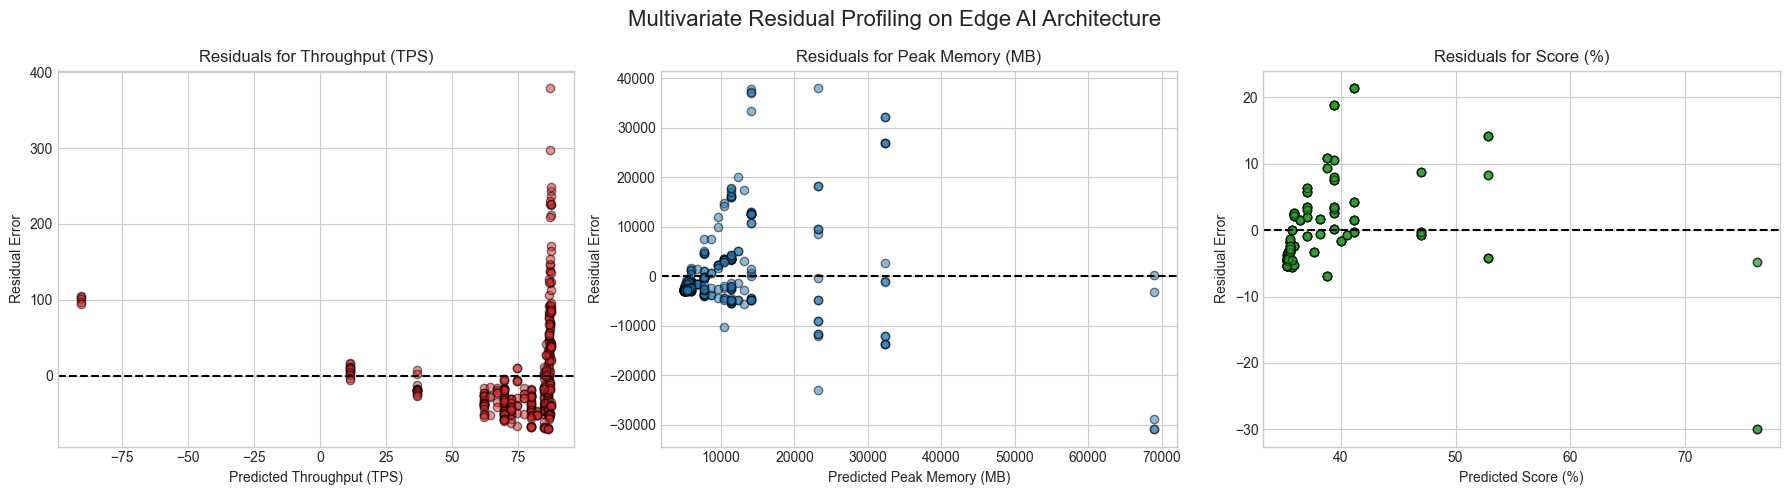

In [10]:
# Visualizing the Multivariate Residuals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Multivariate Residual Profiling on Edge AI Architecture', fontsize=16)

colors = ['#d62728', '#1f77b4', '#2ca02c']

for i, target in enumerate(Y_targets):
    y_actual = Y[:, i]
    y_pred = Y_hat[:, i]
    residuals = y_actual - y_pred
    
    axes[i].scatter(y_pred, residuals, color=colors[i], alpha=0.5, edgecolors='k')
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'Residuals for {target}')
    axes[i].set_xlabel(f'Predicted {target}')
    axes[i].set_ylabel('Residual Error')
    
plt.tight_layout()
plt.show()

### Interpretation: Residual Plots

**Throughput (red):** The residuals show a clear fan/funnel shape — spread increases at higher predicted values. This **heteroscedasticity** indicates the model underestimates uncertainty for high-throughput models (typically small, highly optimised models). A log-transformation of throughput would likely improve this.

**Peak Memory (blue):** The residuals are more evenly spread, consistent with the higher $R^2 = 0.56$. There is a modest positive skew at high memory predictions (very large models like 70B), suggesting the linear model slightly underpredicts memory for the largest models.

**Score (green):** Residuals are centred near zero and relatively uniform, indicating the linear approximation of the accuracy-scale relationship is reasonable across the observed range.

> **Conclusion:** The residual structure confirms that `Params_B` is a meaningful but incomplete predictor. The model successfully captures first-order scale effects while the residual patterns suggest natural extensions: log-transforming throughput, adding architecture-family categorical features, or incorporating training data volume as a proxy for the Chinchilla scaling regime.

---


## Conclusion & Summary

### Key Engineering Insight

Model parameter count (`Params_B`) is the dominant architectural driver of all three performance dimensions:
- **+1B parameters → −2.55 tokens/s, +914 MB memory, +0.58% score**

The large negative off-diagonal covariance between throughput and memory errors ($\approx -95,600$) mathematically confirms what hardware engineers know empirically: *speed and memory are coupled through model scale*. Any model that outperforms predictions on throughput tends to underperform on memory, and vice versa.

### Limitations & Future Work

- Precision (Bits) contributed no information due to zero variance in the dataset; a dataset spanning int4/int8/fp16/fp32 configurations would make this predictor meaningful.
- $R^2 = 0.13$ for Throughput suggests significant unexplained variance — hardware-specific features (GPU generation, batch size, kernel optimisation) are needed.
- A log-linear model for throughput and memory (which grow multiplicatively with scale) would likely improve fit.
